In [1]:
import numpy as np
import matplotlib.pyplot as plt

# optional but recommended
try:
    import cv2
except ImportError:
    !pip -q install opencv-python
    import cv2

def show(img, title="", cmap=None):
    plt.figure(figsize=(5,5))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or "gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

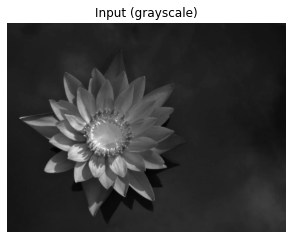

In [2]:
# change filename after uploading via Jupyter file browser
pathOne = "Input_data/flower.png"
bgrOne = cv2.imread(pathOne)
assert bgrOne is not None, "Upload an image and set 'path' correctly."
img = cv2.cvtColor(bgrOne, cv2.COLOR_BGR2GRAY)
show(img, "Input (grayscale)", cmap="gray")


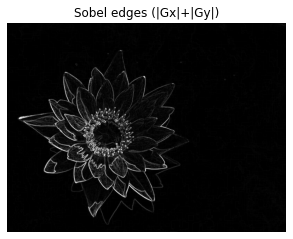

In [3]:
# Sobel gradients (signed)
gx = cv2.Sobel(img, cv2.CV_16S, 1, 0, ksize=3)
gy = cv2.Sobel(img, cv2.CV_16S, 0, 1, ksize=3)

# magnitude approximation (fast, common in HW): |Gx| + |Gy|
mag = np.abs(gx) + np.abs(gy)

# clip to 8-bit for display
edges = np.clip(mag, 0, 255).astype(np.uint8)

show(edges, "Sobel edges (|Gx|+|Gy|)", cmap="gray")


In [4]:
import os
os.makedirs("golden_data", exist_ok=True)

cv2.imwrite("golden_data/flower_input_gray.png", img)
cv2.imwrite("golden_data/flower_edges.png", edges)

print("Saved:", "golden_data/flower_input_gray.png", "and", "golden_data/flower_edges.png")


Saved: golden_data/flower_input_gray.png and golden_data/flower_edges.png


In [5]:
def sobel_reference(img_gray):
    gx = cv2.Sobel(img_gray, cv2.CV_16S, 1, 0, ksize=3)
    gy = cv2.Sobel(img_gray, cv2.CV_16S, 0, 1, ksize=3)
    mag = np.abs(gx) + np.abs(gy)
    return np.clip(mag, 0, 255).astype(np.uint8)


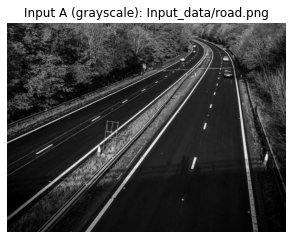

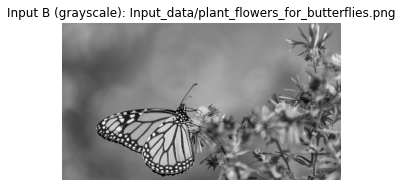

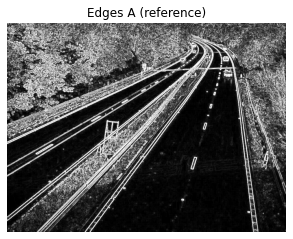

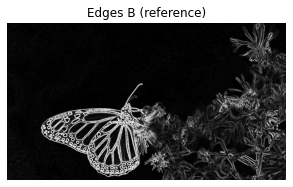

Saved:
  golden_data/road_input.png
  golden_data/road_edges.png
  golden_data/plant_flowers_for_butterflies_input.png
  golden_data/plant_flowers_for_butterflies_edges.png


In [6]:
import os
os.makedirs("golden_data", exist_ok=True)

pathTwo = "Input_data/road.png"
pathThree = "Input_data/plant_flowers_for_butterflies.png"

# --- Load + grayscale ---
bgrTwo = cv2.imread(pathTwo)
assert bgrTwo is not None, f"Could not read {pathTwo}"
imgA = cv2.cvtColor(bgrTwo, cv2.COLOR_BGR2GRAY)
show(imgA, f"Input A (grayscale): {pathTwo}", cmap="gray")

bgrThree = cv2.imread(pathThree)
assert bgrThree is not None, f"Could not read {pathThree}"
imgB = cv2.cvtColor(bgrThree, cv2.COLOR_BGR2GRAY)
show(imgB, f"Input B (grayscale): {pathThree}", cmap="gray")

# --- Sobel reference ---
edgesA = sobel_reference(imgA)
edgesB = sobel_reference(imgB)

show(edgesA, "Edges A (reference)", cmap="gray")
show(edgesB, "Edges B (reference)", cmap="gray")

# --- Save with unique names (no overwriting) ---
baseA = os.path.splitext(os.path.basename(pathTwo))[0]
baseB = os.path.splitext(os.path.basename(pathThree))[0]

cv2.imwrite(f"golden_data/{baseA}_input.png", imgA)
cv2.imwrite(f"golden_data/{baseA}_edges.png", edgesA)

cv2.imwrite(f"golden_data/{baseB}_input.png", imgB)
cv2.imwrite(f"golden_data/{baseB}_edges.png", edgesB)

print("Saved:")
print(f"  golden_data/{baseA}_input.png")
print(f"  golden_data/{baseA}_edges.png")
print(f"  golden_data/{baseB}_input.png")
print(f"  golden_data/{baseB}_edges.png")


In [7]:
img = cv2.imread(pathOne, cv2.IMREAD_GRAYSCALE)
assert img is not None

img256 = cv2.resize(img, (256,256), interpolation=cv2.INTER_AREA)
cv2.imwrite("real_256.pgm", img256)  # PGM is perfect for HLS testbenches
print("Saved real_256.pgm", img256.shape, img256.dtype)

Saved real_256.pgm (256, 256) uint8
